C:\Users\fs\AppData\Local\Temp\ipykernel_11028\3816631227.py:108: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(fac2*ymin, 1.0/fac2*ymax)
C:\Users\fs\AppData\Local\Temp\ipykernel_11028\3816631227.py:114: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(fac2*y1smin, 1.0/fac2*y1smax)
C:\Users\fs\AppData\Local\Temp\ipykernel_11028\3816631227.py:108: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(fac2*ymin, 1.0/fac2*ymax)
C:\Users\fs\AppData\Local\Temp\ipykernel_11028\3816631227.py:114: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(fac2*y1smin, 1.0/fac2*y1smax)
C:\Users\fs\AppData\Local\Temp\ipykernel_11028\3816631227.py:108: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(fac2*ymin, 1.0/fac2*ymax)
C:\Users\fs\AppData\Local\Temp\ipykernel

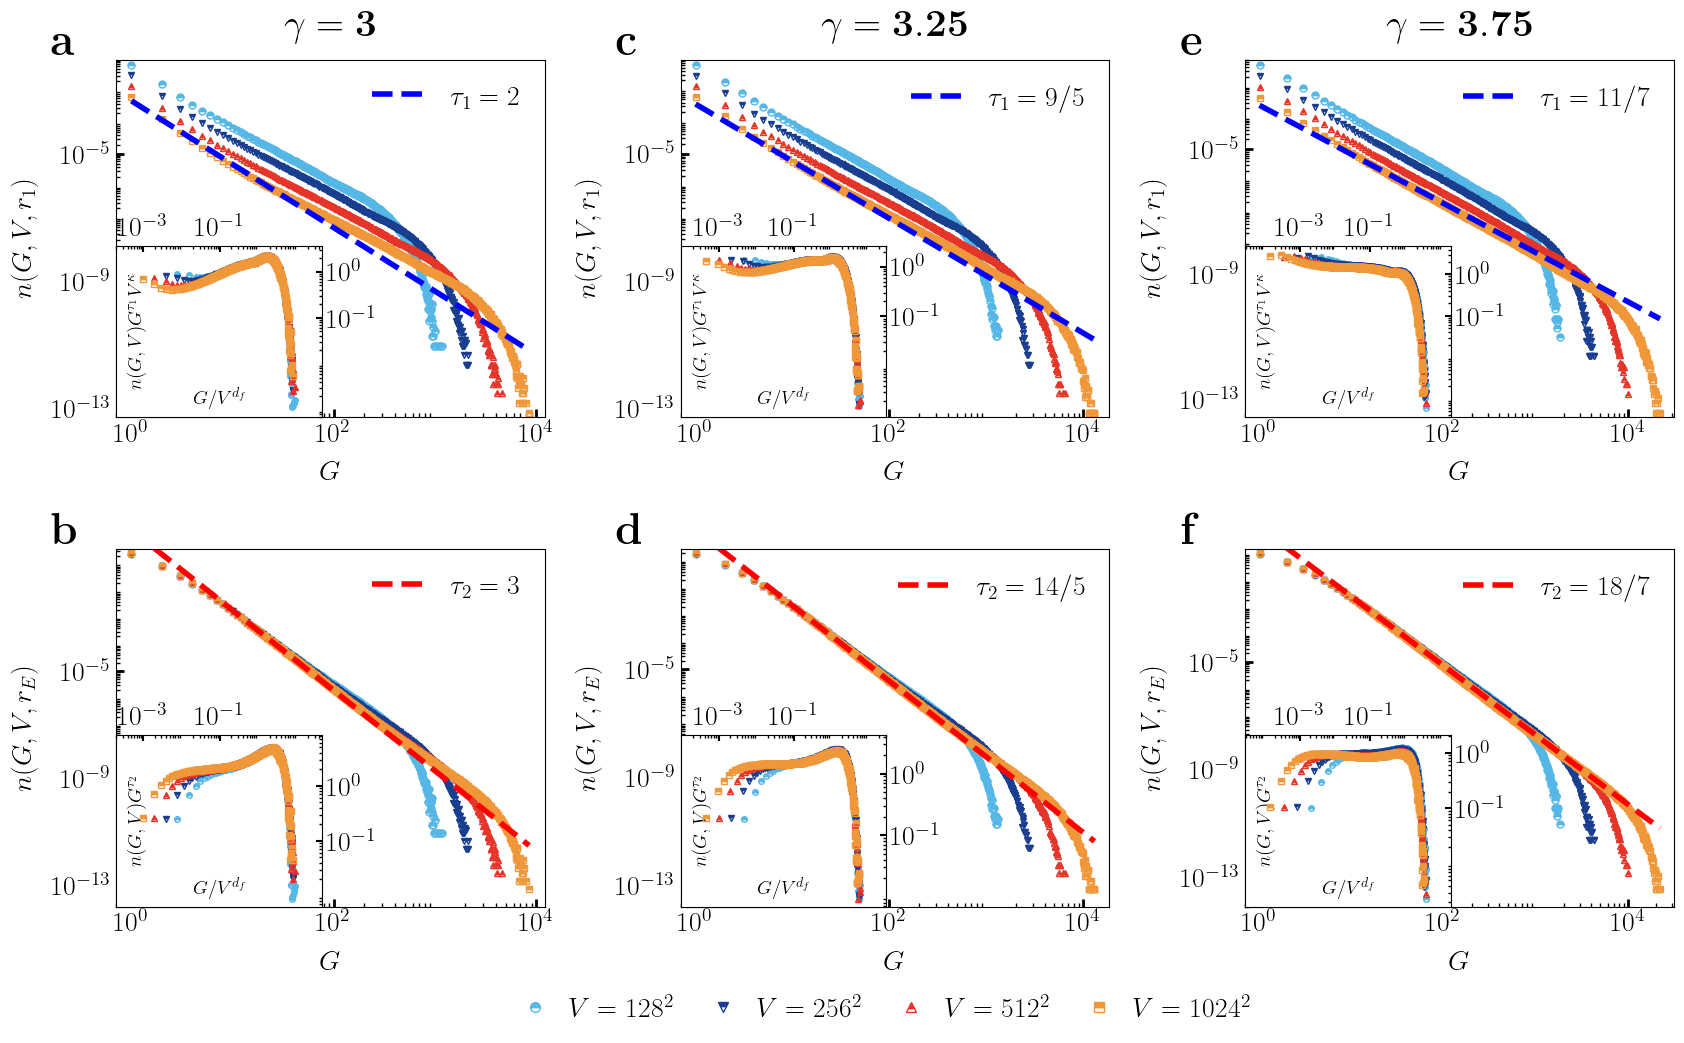

In [ ]:
def SetMainAxes(ax, xlab, ylab, ft = 20, xlabPad=10, ylabPad=10):
    ''' 
        xlab-> xlabel, ft -> fontsize, wifac -> scaling factor of ticks 
        xlabPad -> labelpad of xlabel
    '''
    
    ax.set_xscale('log') 
    ax.set_yscale('log')
    
    ax.set_xticks([1e0, 1e2, 1e4])
    ax.set_yticks([1e-5, 1e-9, 1e-13])    

    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))

    # 设置主刻度
    ax.tick_params(axis='x', which='major', direction='in', width=2, length=6, colors='black', labelsize=20)
    ax.tick_params(axis='y', which='major', direction='in', width=2, length=6, colors='black', labelsize=20)
    # 设置次刻度
    ax.tick_params(axis='x', which='minor', direction='in', width=1, length=3, colors='black')
    ax.tick_params(axis='y', which='minor', direction='in', width=1, length=3, colors='black')
    ax.set_xlabel(xlab, fontsize=ft, labelpad=xlabPad)
    ax.set_ylabel(ylab, fontsize=ft, labelpad=ylabPad)

    return 

def SetSubAxes(ax, xlab, ylab, ft = 14, xlabPad=-25, ylabPad=-25):
    ''' 
        xlab-> xlabel, ft -> fontsize, wifac -> scaling factor of ticks 
        xlabPad -> labelpad of xlabel
    '''
    
    ax.set_xscale('log') 
    ax.set_yscale('log')
    ax.set_xticks([1e-3, 1e-1])
    ax.set_yticks([1e0, 1e-1])
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1, numticks=20))

    # 设置子图刻度在顶部和右侧
    ax.tick_params(axis='x', which='major', direction='in', width=1.5, length=4, colors='black', labelsize=20, labeltop=True, top=True, bottom=False, labelbottom=False)
    ax.tick_params(axis='y', which='major', direction='in', width=1.5, length=4, colors='black', labelsize=20, labelright=True, right=True, left=False, labelleft=False)
    ax.tick_params(axis='x', which='minor', direction='in', width=1  , length=2, colors='black', top=True  , bottom=False)
    ax.tick_params(axis='y', which='minor', direction='in', width=1  , length=2, colors='black', right=True, left=False)

    # 设置子图标签
    ax.set_xlabel(xlab, fontsize=ft, labelpad=xlabPad)
    ax.set_ylabel(ylab, fontsize=ft, labelpad=ylabPad)
    ax.xaxis.set_label_position('bottom')
    ax1.yaxis.set_label_position('left')
#    ax1.yaxis.set_label_coords(0.15, 0.40)
    return 


def CalMinMax(x1, y1, xmin, xmax, ymin, ymax):

    x1min = min(x1); x1max = max(x1); y1min = min(y1); y1max = max(y1)
    xmin = min(xmin, x1min)
    xmax = max(xmax, x1max)
    ymin = min(ymin, y1min)
    ymax = max(ymax, y1max)

    return [xmin, xmax, ymin, ymax]

def ReadPlot(FileArr, ax, ax1, tau, kappa, DF,taus ):
    
    xmin   = 1e12; xmax   = 1e-12; ymin   = 1e12; ymax   = 1e-12
    x1smin = 1e12; x1smax = 1e-12; y1smin = 1e12; y1smax = 1e-12

    tauvar = 1 if kappa >0 else 2
    colT = "blue" if kappa > 0 else "red"

    for k in range(len(FileArr)):
        fname1 = FileArr[k]; 
        L1 = SysSizeArr[k]; V1 = L1**2
        try:
            df1 = pd.read_csv(fname1, sep=r"\s+", skiprows=1, header=None) 
            da1 = np.array(df1)
            x1 = da1[:,1]; y1 = da1[:,3]

            xmin, xmax, ymin, ymax = CalMinMax(x1, y1, xmin, xmax, ymin, ymax)        

            ax.plot(x1, y1, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k], markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')

            if fname1 == FileArr[-1]:
                amp = y1[20]*x1[20]**tau
                yT = amp/x1**tau
                ax.plot(x1, yT, color=colT, linestyle='--', linewidth=4, label=f"$\\tau_{tauvar}={taus}$")

            # 子图数据变换
            x1s = [x11/V1**DF for x11 in x1]
            y1s = [y1[i1]*(x1[i1]**tau)*V1**kappa for i1 in range(len(x1))]

            x1smin, x1smax, y1smin, y1smax = CalMinMax(x1s, y1s, x1smin, x1smax, y1smin, y1smax)        

            ax1.plot(x1s, y1s, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k]-1, markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')
        except Exception as e:
            print(f"can not read file {fname1} with error: {e}")
    # 设置主图范围
    fac1 = 0.7; fac2 = 0.7
    ax.set_xlim(fac1*xmin, 1.0/fac1*xmax)
    ax.set_ylim(fac2*ymin, 1.0/fac2*ymax)
    ax.legend(loc='upper right', fontsize=20, frameon=False, framealpha=0.9)

    # 设置子图范围
    fac1 = 0.2; fac2 = 0.6
    ax1.set_xlim(fac1*x1smin, 1.0/fac1*x1smax)
    ax1.set_ylim(fac2*y1smin, 1.0/fac2*y1smax)
    # 增强边框视觉效果
#    for spine in ax.spines.values():
#        spine.set_linewidth(2)
#    for spine in ax1.spines.values():
#        spine.set_linewidth(2)

    return 


import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import networkx as nx
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.patches as patches 
from matplotlib.lines import Line2D  # 需要导入Line2D
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# global parameter 
global ColorArr, MarkerArr, MarSizArr
global Kappaexpos, Tau1expos, Tau2expos, Tau1Sexpos, Tau2Sexpos, SysSizeArr

# Figure setting  
plt.rcParams['text.usetex'] = True 
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 20})  # 稍微减小字体以适应多子图
figsize = (18, 10)  # 增大图形尺寸
#ColorArr  = ['black', 'blue', 'red', 'orange', 'green']
ColorArr =["#55B7E6", "#193E8F", "#E53528", "#F09739"]


MarkerArr = ['o', 'v', '^', 's', 'D']
MarSizArr = [5, 5, 5, 5, 5]  # 稍微减小标记大小

# inset figure setting 
sub_width   = 0.25 
sub_height  = 0.12
left_shift  =-0.0285
bottom_shift =-0.0065
    
# Read File 
SubDirs = ["SF300", "SF325", "SF375"]
Kappaexpos = [1/2, 5/9, 7/11]
Tau1expos  = [2, 9/5, 11/7] 
Tau1Sexpos  = ["2", "9/5", "11/7"] 
DFexpos    = [1/2, 5/9, 7/11]
Tau2expos  = [3, 14/5, 18/7]
Tau2Sexpos  = ["3", "14/5", "18/7"]
#SysSizeArr = [256, 512, 1024, 2048]
SysSizeArr = [128, 256, 512, 1024]


Curdir = os.getcwd() 

# 创建4×2的子图布局
fig, axes = plt.subplots(2, 3, figsize=figsize)


for sub1 in range(len(SubDirs)):
    ssys = SubDirs[sub1]
    path1  = os.path.join(Curdir, f"../{ssys}/")

    DatDir = os.path.normpath(path1) 

    ax = axes[0, sub1]
    xlable = "$G$"; ylable= "$n(G, V, r_1)$"
    SetMainAxes(ax, xlable, ylable, ft = 20,  xlabPad=10, ylabPad=10)

    ax1 = inset_axes(ax, width="48%", height="48%", loc="lower left", bbox_to_anchor=(0,0,1,1), bbox_transform=ax.transAxes, borderpad=0)
    xlable = "$G/V^{d_f}$"; ylable= "$n(G, V)G^{\\tau_1}V^{\\kappa}$"
    SetSubAxes(ax1, xlable, ylable, ft = 14, xlabPad=-25, ylabPad=-25)

    str1 = "ns.His1Dc1_L"
    FileArr = [os.path.join(DatDir, str1 + str(s1)) for s1 in SysSizeArr]
    tau = Tau1expos[sub1]; kappa = Kappaexpos[sub1]; DF = DFexpos[sub1]; taus = Tau1Sexpos[sub1] 
    ReadPlot(FileArr, ax, ax1, tau, kappa, DF, taus)

    label_text = chr(97 + sub1*2)
    ax.text(-0.15, 1.10, r'$\mathbf{' + label_text +'}$', transform=ax.transAxes, 
            fontsize=32, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')

    
    ax = axes[1, sub1]
    xlable = "$G$"; ylable= "$n(G, V, r_E)$"
    SetMainAxes(ax, xlable, ylable, ft = 20, xlabPad=10, ylabPad=10)

    ax1 = inset_axes(ax, width="48%", height="48%", loc="lower left", bbox_to_anchor=(0,0,1,1), bbox_transform=ax.transAxes, borderpad=0)
    xlable = "$G/V^{d_f}$"; ylable= "$n(G, V)G^{\\tau_2}$"
    SetSubAxes(ax1, xlable, ylable, ft = 14, xlabPad=-25, ylabPad=-25)

    str1 = "ns.HisDc1_L"
    FileArr = [os.path.join(DatDir, str1 + str(s1)) for s1 in SysSizeArr]
    tau = Tau2expos[sub1]; kappa = 0; DF = DFexpos[sub1]; taus = Tau2Sexpos[sub1] 
    ReadPlot(FileArr, ax, ax1, tau, kappa, DF, taus)

    label_text = chr(97 + sub1*2+1)
    ax.text(-0.15, 1.10, r'$\mathbf{' + label_text +'}$', transform=ax.transAxes, 
            fontsize=32, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')



# 创建图例元素
legend_elements = [Line2D([0], [0], marker=MarkerArr[k], color=ColorArr[k], 
                   markerfacecolor=ColorArr[k], markersize=MarSizArr[k] + 2,  # 稍微增大图例中的标记大小
                   fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k], 
                   linestyle='None', label=f'$V={SysSizeArr[k]}^2$') for k in range(len(SysSizeArr))]

# 将图例放在图的最下面，横向排列
fig.legend(handles=legend_elements,
           loc='lower center',           # 放在底部中央
           bbox_to_anchor=(0.5, -0.05),   # 调整垂直位置
           ncol=5,                       # 横向排列，5列
           fontsize=20,                  # 图例字体大小
           frameon=False,                 # 显示图例框
           fancybox=True,                # 圆角边框
           shadow=False,                 # 无阴影
           handletextpad=0.5,            # 标记和文本间距
           columnspacing=1.0,            # 列间距
           handlelength=1.5)             # 标记长度

# 调整子图间距，为底部图例留出空间
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
#plt.tight_layout()
plt.subplots_adjust(bottom=0.09)  # 增加底部边距，为图例留出空间
plt.subplots_adjust(right=0.94)
#right_x = 0.98
right_y = 0.97
#GaVas =['\gamma=3', '\gamma=3.25', '\gamma=3.75']
GaVas =["\\gamma=3", "\\gamma=3.25", "\\gamma=3.75"]
for i, lab in enumerate(GaVas):
    pos = axes[0, i].get_position()
#    y_center = pos.y0 + pos.height/2
    x_center = pos.x0 + pos.width/2
#    t = fig.text(right_x, y_center, r'$\mathbf{' + lab +'}$', ha='center', va='center', fontsize=28, fontweight='bold', color='black')
    t = fig.text(x_center, right_y, r'$\mathbf{' + lab +'}$', ha='center', va='center', fontsize=28, fontweight='bold', color='black')
    t.set_clip_on(False)

plt.savefig("FigS4.pdf", bbox_inches='tight')
plt.show()
